# Appendix. HDBSCAN Robustness Check
 
This notebook evaluates the trained GAT-GAE/HAN-GAE models using HDBSCAN to ensure the clustering results are robust and not merely artifacts of K-Means.

In [1]:
"""
# Colab setup (optional)
!git clone https://github.com/c2g-dev/city2graph-case-study.git

import os
REPO_DIR = "/content/city2graph-case-study"
os.chdir(REPO_DIR)

# delete data directory
!rm -rf /content/city2graph-case-study/data

# download data zip from Zenodo and unzip into data/
!wget -O /content/city2graph-case-study/data.zip https://zenodo.org/records/19402242/files/data.zip?download=1
!unzip -o /content/city2graph-case-study/data.zip -d /content/city2graph-case-study/

# install uv and sync pinned dependencies from uv.lock
!pip install -q uv
!uv export --frozen --no-dev --format requirements-txt -o /tmp/c2g-requirements.txt
!uv pip sync --system /tmp/c2g-requirements.txt

os.chdir(REPO_DIR + "/notebooks")
"""

'\n# Colab setup (optional)\n!git clone https://github.com/c2g-dev/city2graph-case-study.git\n\nimport os\nREPO_DIR = "/content/city2graph-case-study"\nos.chdir(REPO_DIR)\n\n# delete data directory\n!rm -rf /content/city2graph-case-study/data\n\n# download data zip from Zenodo and unzip into data/\n!wget -O /content/city2graph-case-study/data.zip https://zenodo.org/records/19402242/files/data.zip?download=1\n!unzip -o /content/city2graph-case-study/data.zip -d /content/city2graph-case-study/\n\n# install uv and sync pinned dependencies from uv.lock\n!pip install -q uv\n!uv export --frozen --no-dev --format requirements-txt -o /tmp/c2g-requirements.txt\n!uv pip sync --system /tmp/c2g-requirements.txt\n\nos.chdir(REPO_DIR + "/notebooks")\n'

## 1. Setup & Configuration

In [2]:
import sys
import os
import random
sys.path.append(os.path.abspath('..'))

import yaml
import torch
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import pyproj

from matplotlib.colors import to_hex
from matplotlib.patches import Patch
from shapely.geometry import Point
import hdbscan
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

import city2graph as c2g

# Load config
with open('../configs/experiment_config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Set seeds for reproducibility
SEED = config['seeds']['global']
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Pandas display options
pd.options.display.float_format = '{:,.2f}'.format

# Paths
DATA_ROOT = config['data']['root']
EMBEDDINGS_DIR = '../data/outputs/embeddings'
FIGURES_DIR = '../data/outputs/figures'
TABLES_DIR = '../data/outputs/tables'
CLUSTERS_DIR = '../data/outputs/clusters'
MEM_DIR = "./tmp/hdbscan_cache"

for d in [FIGURES_DIR, TABLES_DIR, CLUSTERS_DIR, MEM_DIR]:
    os.makedirs(d, exist_ok=True)

# Model configurations
MODELS = {
    'Baseline (PCA)': {'file': f"../{DATA_ROOT}/{config['data']['homo']}", 'type': 'baseline'},
    'Model 1 (GAT-GAE)': {'file': f"{EMBEDDINGS_DIR}/model1_gat_gae.pt", 'type': 'homo'},
    'Model 2 (HAN-GAE: Walk)': {'file': f"{EMBEDDINGS_DIR}/model2_han_gae_walk.pt", 'type': 'hetero'},
    'Model 3 (HAN-GAE: Multi)': {'file': f"{EMBEDDINGS_DIR}/model3_han_gae_multi.pt", 'type': 'hetero'},
    'Model 4 (HAN-GAE: All)': {'file': f"{EMBEDDINGS_DIR}/model4_han_gae_all.pt", 'type': 'hetero'},
    'Model 1S (GAT-GAE: Struct)': {'file': f"{EMBEDDINGS_DIR}/model1s_gat_gae_struct.pt", 'type': 'homo_struct'},
    'Model 2S (HAN-GAE: Walk-S)': {'file': f"{EMBEDDINGS_DIR}/model2s_han_gae_walk_struct.pt", 'type': 'hetero_struct'},
    'Model 3S (HAN-GAE: Multi-S)': {'file': f"{EMBEDDINGS_DIR}/model3s_han_gae_multi_struct.pt", 'type': 'hetero_struct'},
    'Model 4S (HAN-GAE: All-S)': {'file': f"{EMBEDDINGS_DIR}/model4s_han_gae_all_struct.pt", 'type': 'hetero_struct'}
}

# Embedding dimensions and beta dimensions per model
EMBEDDING_COLS = [f'embedding_{i}' for i in range(16)]

# Update to capture both Layer 1 and Layer 2 betas
BETA_COLS = {
    'Model 2 (HAN-GAE: Walk)': [f'beta1_{i}' for i in range(2)] + [f'beta2_{i}' for i in range(2)],
    'Model 3 (HAN-GAE: Multi)': [f'beta1_{i}' for i in range(2)] + [f'beta2_{i}' for i in range(2)],
    'Model 4 (HAN-GAE: All)': [f'beta1_{i}' for i in range(3)] + [f'beta2_{i}' for i in range(3)]
}

RELATION_NAMES = {
    'Model 2 (HAN-GAE: Walk)': ['contig', '15_min_walk'],
    'Model 3 (HAN-GAE: Multi)': ['contig', '15_min_multi'],
    'Model 4 (HAN-GAE: All)': ['contig', '15_min_walk', '15_min_multi']
}

CITY_CENTRE = {'lat': 53.403553, 'lon': -2.986844}  # Liverpool One


## 2. Load Embeddings & Convert to GeoDataFrames

In [3]:
# Load OA polygons for geometry mapping
oa_polygons = gpd.read_file('../data/processed/features/oa_with_features.gpkg').set_index('OA21CD')

# Dictionary to store GeoDataFrames with embeddings
model_gdfs = {}
attention_data = {}

# Load each saved embedding file and convert it into an OA-level GeoDataFrame
for model_name, meta in MODELS.items():
    print(f"\nLoading: {model_name}")
    data = torch.load(meta['file'], map_location='cpu', weights_only=False)

    is_hetero = meta['type'].startswith('hetero')
    beta_cols = BETA_COLS.get(model_name, [])

    # Handle baseline, homogeneous, and heterogeneous model outputs separately
    if meta['type'] == 'baseline':
        nodes_gdf, _ = c2g.pyg_to_gdf(data, node_types='oa')
    elif is_hetero:
        add_cols = {'oa': EMBEDDING_COLS + beta_cols}
        nodes_gdf = c2g.pyg_to_gdf(data, node_types=['oa'], additional_node_cols=add_cols)[0]['oa']
    else:
        nodes_gdf, _ = c2g.pyg_to_gdf(data, additional_node_cols=EMBEDDING_COLS)

    # Extract attention weights for HAN models
    if beta_cols:
        rels = RELATION_NAMES[model_name]
        attention_data[model_name] = {
            f'Layer {li}': nodes_gdf[[f'beta{li}_{i}' for i in range(len(rels))]].set_axis(rels, axis=1)
            for li in [1, 2]
        }

    # Replace geometry with OA polygons for choropleth mapping
    model_gdfs[model_name] = nodes_gdf.set_geometry(
        oa_polygons.loc[nodes_gdf.index, 'geometry']
    )

    print(f"  Loaded {len(model_gdfs[model_name])} OAs")

print("\nLoading base heterogeneous graph for modularity calculation...")
data_multi = torch.load(f"../{DATA_ROOT}/{config['data']['hetero_multi']}", map_location='cpu', weights_only=False)

# Rebuild relation-specific OA graphs used later for modularity scoring
oa_edge_types = [
    ('oa', 'contig', 'oa'),
    ('oa', '15_min_walk', 'oa'),
    ('oa', '15_min_multi', 'oa'),
]

oa_nodes_multi, oa_edges_multi = c2g.pyg_to_gdf(
    data_multi,
    node_types=['oa'],
    edge_types=oa_edge_types,
)

oa_nodes_gdf = oa_nodes_multi['oa']
oa_nodes = list(oa_nodes_gdf.index)

relation_edges = {
    rel: oa_edges_multi[('oa', rel, 'oa')]
    for rel in ['contig', '15_min_walk', '15_min_multi']
}

# Store relations separately for calculating modularity
nx_graphs = {}
for rel, edges_gdf in relation_edges.items():
    G = c2g.gdf_to_nx(nodes=oa_nodes_gdf, edges=edges_gdf)
    G = nx.relabel_nodes(
        G,
        {node_id: attrs['_original_index'] for node_id, attrs in G.nodes(data=True)},
    )
    nx_graphs[rel] = G
    print(f"  Extracted {rel} graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Loading: Baseline (PCA)
  Loaded 1624 OAs

Loading: Model 1 (GAT-GAE)
  Loaded 1624 OAs

Loading: Model 2 (HAN-GAE: Walk)
  Loaded 1624 OAs

Loading: Model 3 (HAN-GAE: Multi)
  Loaded 1624 OAs

Loading: Model 4 (HAN-GAE: All)
  Loaded 1624 OAs

Loading: Model 1S (GAT-GAE: Struct)
  Loaded 1624 OAs

Loading: Model 2S (HAN-GAE: Walk-S)
  Loaded 1624 OAs

Loading: Model 3S (HAN-GAE: Multi-S)
  Loaded 1624 OAs

Loading: Model 4S (HAN-GAE: All-S)
  Loaded 1624 OAs

Loading base heterogeneous graph for modularity calculation...
  Extracted contig graph: 1624 nodes, 4782 edges
  Extracted 15_min_walk graph: 1624 nodes, 28265 edges
  Extracted 15_min_multi graph: 1624 nodes, 69403 edges


## 3. Clustering Pipeline

For each model:
1. L2-normalize embeddings
2. Search for optimal HDBSCAN hyperparameter (`min_cluster_size`) via DBCV
3. Save best clustering results

In [4]:
# Configuration
MCS_RANGE = list(range(5, 31, 1))

In [5]:
def get_embeddings(gdf, model_type):
    """Extract embedding matrix from GeoDataFrame."""
    if model_type == 'baseline':
        feat_cols = [c for c in gdf.columns if c not in ['geometry', 'cluster', 'cluster_label_rank'] and gdf[c].dtype in ['float64', 'float32', 'int64']]
        Z = gdf[feat_cols].values
        pca = PCA(n_components=len(EMBEDDING_COLS), random_state=config['seeds']['global'])
        Z = pca.fit_transform(Z)
    else:
        Z = gdf[EMBEDDING_COLS].values
    return normalize(Z, norm='l2')

def optimal_k_clustering(Z, nx_graphs, oa_nodes, mcs_range):
    """Find optimal hyperparameter for DBCV using only min_cluster_size."""

    # HPO search over min_cluster_size only
    results_by_k = {}
    for mcs in mcs_range:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            gen_min_span_tree=True,
            memory=MEM_DIR,
        )
        labels = clusterer.fit_predict(Z)

        # Filter out noise points
        valid_mask = labels != -1
        n_clusters = len(set(labels[valid_mask]))

        # Calculate metrics
        dbcv = clusterer.relative_validity_

        mods = {'contig': np.nan, '15_min_walk': np.nan, '15_min_multi': np.nan}
        if len(oa_nodes) == len(labels):
            # Exclude noise points from modularity calculation completely
            valid_nodes = set()
            communities = [set() for _ in range(n_clusters)]
            for i, cluster_id in enumerate(labels):
                if cluster_id != -1:
                    communities[cluster_id].add(oa_nodes[i])
                    valid_nodes.add(oa_nodes[i])
            for rel, G in nx_graphs.items():
                sub_G = G.subgraph(valid_nodes)
                if sub_G.number_of_edges() > 0:
                    mods[rel] = nx.community.modularity(sub_G, communities)

        config_result = {
            'mcs': mcs,
            'labels': labels,
            'dbcv': dbcv,
            'modularity_contig': mods.get('contig', np.nan),
            'modularity_walk': mods.get('15_min_walk', np.nan),
            'modularity_multi': mods.get('15_min_multi', np.nan),
        }

        if n_clusters not in results_by_k or dbcv > results_by_k[n_clusters]['dbcv']:
            results_by_k[n_clusters] = config_result

    # Reconstruct k_df
    k_scores = []
    for k, res in sorted(results_by_k.items()):
        row = {'k': k, **res}
        del row['labels']
        k_scores.append(row)

    k_df = pd.DataFrame(k_scores)

    # Best overall configuration across all K
    best_k = int(k_df.loc[k_df['dbcv'].idxmax(), 'k'])
    best = results_by_k[best_k]

    return {
        'k': best_k,
        'mcs': best['mcs'],
        'dbcv': best['dbcv'],
        'labels': best['labels'],
        'modularity_contig': best['modularity_contig'],
        'modularity_walk': best['modularity_walk'],
        'modularity_multi': best['modularity_multi'],
        'k_search': k_df,
    }

# Run clustering for all models
clustering_results = {}

for model_name, gdf in model_gdfs.items():
    print(f"\nClustering: {model_name}")
    Z = get_embeddings(gdf, MODELS[model_name]['type'])
    result = optimal_k_clustering(Z, nx_graphs, oa_nodes, MCS_RANGE)

    # Add cluster labels to GeoDataFrame
    gdf['cluster'] = result['labels']
    clustering_results[model_name] = result

    # Save cluster assignments
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    gdf[['cluster']].to_csv(f"{CLUSTERS_DIR}/{safe_name}_hdbscan.csv")

    print(f"  Optimal: K={result['k']} (mcs={result['mcs']}, DBCV={result['dbcv']:.2f})")


Clustering: Baseline (PCA)
  Optimal: K=17 (mcs=9, DBCV=0.14)

Clustering: Model 1 (GAT-GAE)
  Optimal: K=19 (mcs=6, DBCV=0.27)

Clustering: Model 2 (HAN-GAE: Walk)
  Optimal: K=32 (mcs=9, DBCV=0.27)

Clustering: Model 3 (HAN-GAE: Multi)
  Optimal: K=14 (mcs=15, DBCV=0.38)

Clustering: Model 4 (HAN-GAE: All)
  Optimal: K=16 (mcs=18, DBCV=0.34)

Clustering: Model 1S (GAT-GAE: Struct)
  Optimal: K=3 (mcs=14, DBCV=0.02)

Clustering: Model 2S (HAN-GAE: Walk-S)
  Optimal: K=5 (mcs=17, DBCV=0.10)

Clustering: Model 3S (HAN-GAE: Multi-S)
  Optimal: K=7 (mcs=17, DBCV=0.03)

Clustering: Model 4S (HAN-GAE: All-S)
  Optimal: K=3 (mcs=5, DBCV=0.00)


## 3.5 Cluster Statistics (Table 2)
Display the range (min-max) of each index by clusters.

In [6]:
def mean_std_str(s):
    if s.empty:
        return "N/A"
    mean = s.mean()
    std = 0.0 if len(s) == 1 else s.std()
    return f"{mean:.2f} ± {std:.2f}"

data = {}
for model_name, result in clustering_results.items():
    k_df = result["k_search"]
    dbcv = k_df["dbcv"]
    mc = k_df["modularity_contig"].dropna()
    mw = k_df["modularity_walk"].dropna()
    mm = k_df["modularity_multi"].dropna()

    data[model_name] = {
        ("DBCV", "Mean ± SD"): mean_std_str(dbcv),
        ("Modularity (Contig)", "Mean ± SD"): mean_std_str(mc),
        ("Modularity (Walk)", "Mean ± SD"): mean_std_str(mw),
        ("Modularity (Multi)", "Mean ± SD"): mean_std_str(mm),
    }

df_results_range = pd.DataFrame(data).T
df_results_range.columns.names = ["Metric", "Statistic"]

display(df_results_range)
df_results_range.to_csv(f"{TABLES_DIR}/cluster_stats_hdbscan.csv")


Metric,DBCV,Modularity (Contig),Modularity (Walk),Modularity (Multi)
Statistic,Mean ± SD,Mean ± SD,Mean ± SD,Mean ± SD
Baseline (PCA),0.10 ± 0.04,0.26 ± 0.06,0.17 ± 0.05,0.06 ± 0.02
Model 1 (GAT-GAE),0.07 ± 0.08,0.53 ± 0.13,0.53 ± 0.10,0.28 ± 0.07
Model 2 (HAN-GAE: Walk),0.20 ± 0.06,0.91 ± 0.01,0.84 ± 0.04,0.24 ± 0.08
Model 3 (HAN-GAE: Multi),0.20 ± 0.08,0.86 ± 0.02,0.77 ± 0.07,0.45 ± 0.14
Model 4 (HAN-GAE: All),0.19 ± 0.08,0.84 ± 0.23,0.78 ± 0.23,0.37 ± 0.13
Model 1S (GAT-GAE: Struct),0.02 ± 0.00,0.01 ± 0.00,0.00 ± 0.00,-0.00 ± 0.00
Model 2S (HAN-GAE: Walk-S),0.03 ± 0.04,0.02 ± 0.02,0.00 ± 0.01,-0.00 ± 0.00
Model 3S (HAN-GAE: Multi-S),0.01 ± 0.01,0.01 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
Model 4S (HAN-GAE: All-S),0.00 ± 0.00,0.00 ± 0.01,0.00 ± 0.00,-0.00 ± 0.00


In [7]:
clustering_results["Model 1S (GAT-GAE: Struct)"]["k_search"]

,k,mcs,dbcv,modularity_contig,modularity_walk,modularity_multi
0,3,14,0.02,0.01,0.00,-0.00


## 6. Cluster Map Visualizations

In [8]:
# Shared setup for map visualizations

# Transform city centre to projected CRS
transformer = pyproj.Transformer.from_crs('EPSG:4326', model_gdfs['Model 1 (GAT-GAE)'].crs, always_xy=True)
centre_x, centre_y = transformer.transform(CITY_CENTRE['lon'], CITY_CENTRE['lat'])

# Find the OA containing or nearest to the city centre
ref_gdf = model_gdfs['Model 1 (GAT-GAE)']
centre_oa_idx = ref_gdf.geometry.distance(Point(centre_x, centre_y)).idxmin()
print(f"City centre OA: {centre_oa_idx}")

# Global categorical palette (shuffled for visual distinctness)
base_palette = (sns.color_palette("bright", 10) + sns.color_palette("dark", 10) +
                sns.color_palette("husl", 15) + sns.color_palette("pastel", 15))
rng = np.random.RandomState(42)
GLOBAL_COLORS = [to_hex(c) for c in base_palette]
rng.shuffle(GLOBAL_COLORS)

# Split models: proposed vs baselines
proposed_models = [m for m in model_gdfs if 'S (' not in m and m != 'Baseline (PCA)']
baseline_models = ['Baseline (PCA)'] + [m for m in model_gdfs if 'S (' in m]

# Models that should NOT show per-polygon rank labels
NO_RANK_LABELS = {
    "Baseline (PCA)",
    "Model 1S (GAT-GAE: Struct)", "Model 2S (HAN-GAE: Walk-S)",
    "Model 3S (HAN-GAE: Multi-S)", "Model 4S (HAN-GAE: All-S)",
}


def adjust_component_labels(ax, labels, padding=2.0, max_iter=500):
    """Separate overlapping component labels and connect displaced labels to anchors."""
    if len(labels) < 2:
        return
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    anchors = np.array([ax.transData.transform(anchor) for _, anchor in labels], dtype=float)
    positions = anchors.copy()
    extents = [text.get_window_extent(renderer=renderer) for text, _ in labels]
    widths = np.array([extent.width for extent in extents])
    heights = np.array([extent.height for extent in extents])
    axes_bbox = ax.get_window_extent(renderer=renderer)
    for _ in range(max_iter):
        moved = False
        for i in range(len(labels)):
            for j in range(i + 1, len(labels)):
                delta = positions[j] - positions[i]
                overlap_x = (widths[i] + widths[j]) / 2 + padding - abs(delta[0])
                overlap_y = (heights[i] + heights[j]) / 2 + padding - abs(delta[1])
                if overlap_x <= 0 or overlap_y <= 0:
                    continue
                moved = True
                if overlap_x < overlap_y:
                    direction = 1.0 if delta[0] > 0 or (delta[0] == 0 and j > i) else -1.0
                    shift = direction * overlap_x / 2
                    positions[i, 0] -= shift
                    positions[j, 0] += shift
                else:
                    direction = 1.0 if delta[1] > 0 or (delta[1] == 0 and j > i) else -1.0
                    shift = direction * overlap_y / 2
                    positions[i, 1] -= shift
                    positions[j, 1] += shift
        positions[:, 0] = np.clip(positions[:, 0], axes_bbox.x0 + widths / 2, axes_bbox.x1 - widths / 2)
        positions[:, 1] = np.clip(positions[:, 1], axes_bbox.y0 + heights / 2, axes_bbox.y1 - heights / 2)
        if not moved:
            break
    inverse = ax.transData.inverted()
    for (text, anchor), display_position, original_position in zip(labels, positions, anchors):
        data_position = inverse.transform(display_position)
        text.set_position(data_position)
        if np.linalg.norm(display_position - original_position) > 4:
            ax.annotate('', xy=anchor, xytext=data_position,
                        arrowprops={'arrowstyle': '-', 'color': '0.25', 'linewidth': 0.6, 'alpha': 0.7},
                        zorder=text.get_zorder() - 0.1)


def plot_cluster_map(ax, gdf, result, model_name):
    """Plot a single model's cluster map on *ax*."""
    Z = get_embeddings(gdf, MODELS[model_name]['type'])

    # Cosine similarity ranking relative to city-centre cluster
    centre_pos = list(gdf.index).index(centre_oa_idx)
    target_label = result['labels'][centre_pos]
    target_label = target_label if target_label != -1 else [l for l in result['labels'] if l != -1][0]
    centroids = pd.DataFrame(Z).assign(label=result['labels'])
    centroids = centroids[centroids['label'] != -1].groupby('label').mean()
    target_vec = centroids.loc[target_label].values.reshape(1, -1)
    cluster_sims = dict(zip(centroids.index, cosine_similarity(target_vec, centroids.values)[0]))

    sorted_labels = sorted(cluster_sims, key=cluster_sims.get, reverse=True)
    label_to_rank = {label: i for i, label in enumerate(sorted_labels)}
    rank_color_map = {label: GLOBAL_COLORS[i % len(GLOBAL_COLORS)] for i, label in enumerate(sorted_labels)}
    node_colors = [rank_color_map[l] if l != -1 else '#CCCCCC' for l in result['labels']]

    # Plot polygons
    c2g.plot_graph(
        nodes=gdf,
        ax=ax,
        node_color=node_colors,
        node_edgecolor='white',
        node_alpha=1,
        linewidth=0.1, 
        bgcolor='white'
        )

    # Add a rank label to each disconnected component, matching 04_evaluation.ipynb.
    component_labels = []
    if model_name not in NO_RANK_LABELS:
        valid_mask = np.asarray(result['labels']) != -1
        gdf_temp = gdf.loc[valid_mask].assign(
            cluster_label_rank=[label_to_rank[label] for label in np.asarray(result['labels'])[valid_mask]]
        )
        dissolved = gdf_temp.dissolve(by='cluster_label_rank').reset_index()
        for _, row in dissolved.iterrows():
            geom = row.geometry
            polys = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom] if geom.geom_type == 'Polygon' else []
            for poly in polys:
                anchor = poly.representative_point()
                text = ax.text(anchor.x, anchor.y, str(row['cluster_label_rank']), fontsize=18,
                               ha='center', va='center', color='black', weight='bold', zorder=10,
                               path_effects=[pe.withStroke(linewidth=3, foreground='white')])
                component_labels.append((text, (anchor.x, anchor.y)))
        adjust_component_labels(ax, component_labels)

    # ── Legend ────────────────────────────────────────────────────
    legend_elements = [
        Patch(facecolor=rank_color_map[ol], edgecolor='white',
              label=f"{i}")
        for i, ol in enumerate(sorted_labels)
    ]
    # Add noise entry
    n_noise = int(np.sum(np.array(result['labels']) == -1))
    if n_noise > 0:
        legend_elements.append(
            Patch(facecolor='#CCCCCC', edgecolor='white',
                  label=f'Noise'))

    if len(legend_elements) > 20:
        ncol = 2
    else:
        ncol = 1

    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5),
              fontsize=16, title='Cluster', title_fontsize=16,
              frameon=False, ncol=ncol)

    # Title
    ax.set_title(f"{model_name}\n(mcs={result['mcs']}, DBCV={result['dbcv']:.2f})",
                 fontsize=24, fontweight='bold')
    ax.set_axis_off()


City centre OA: E00176629


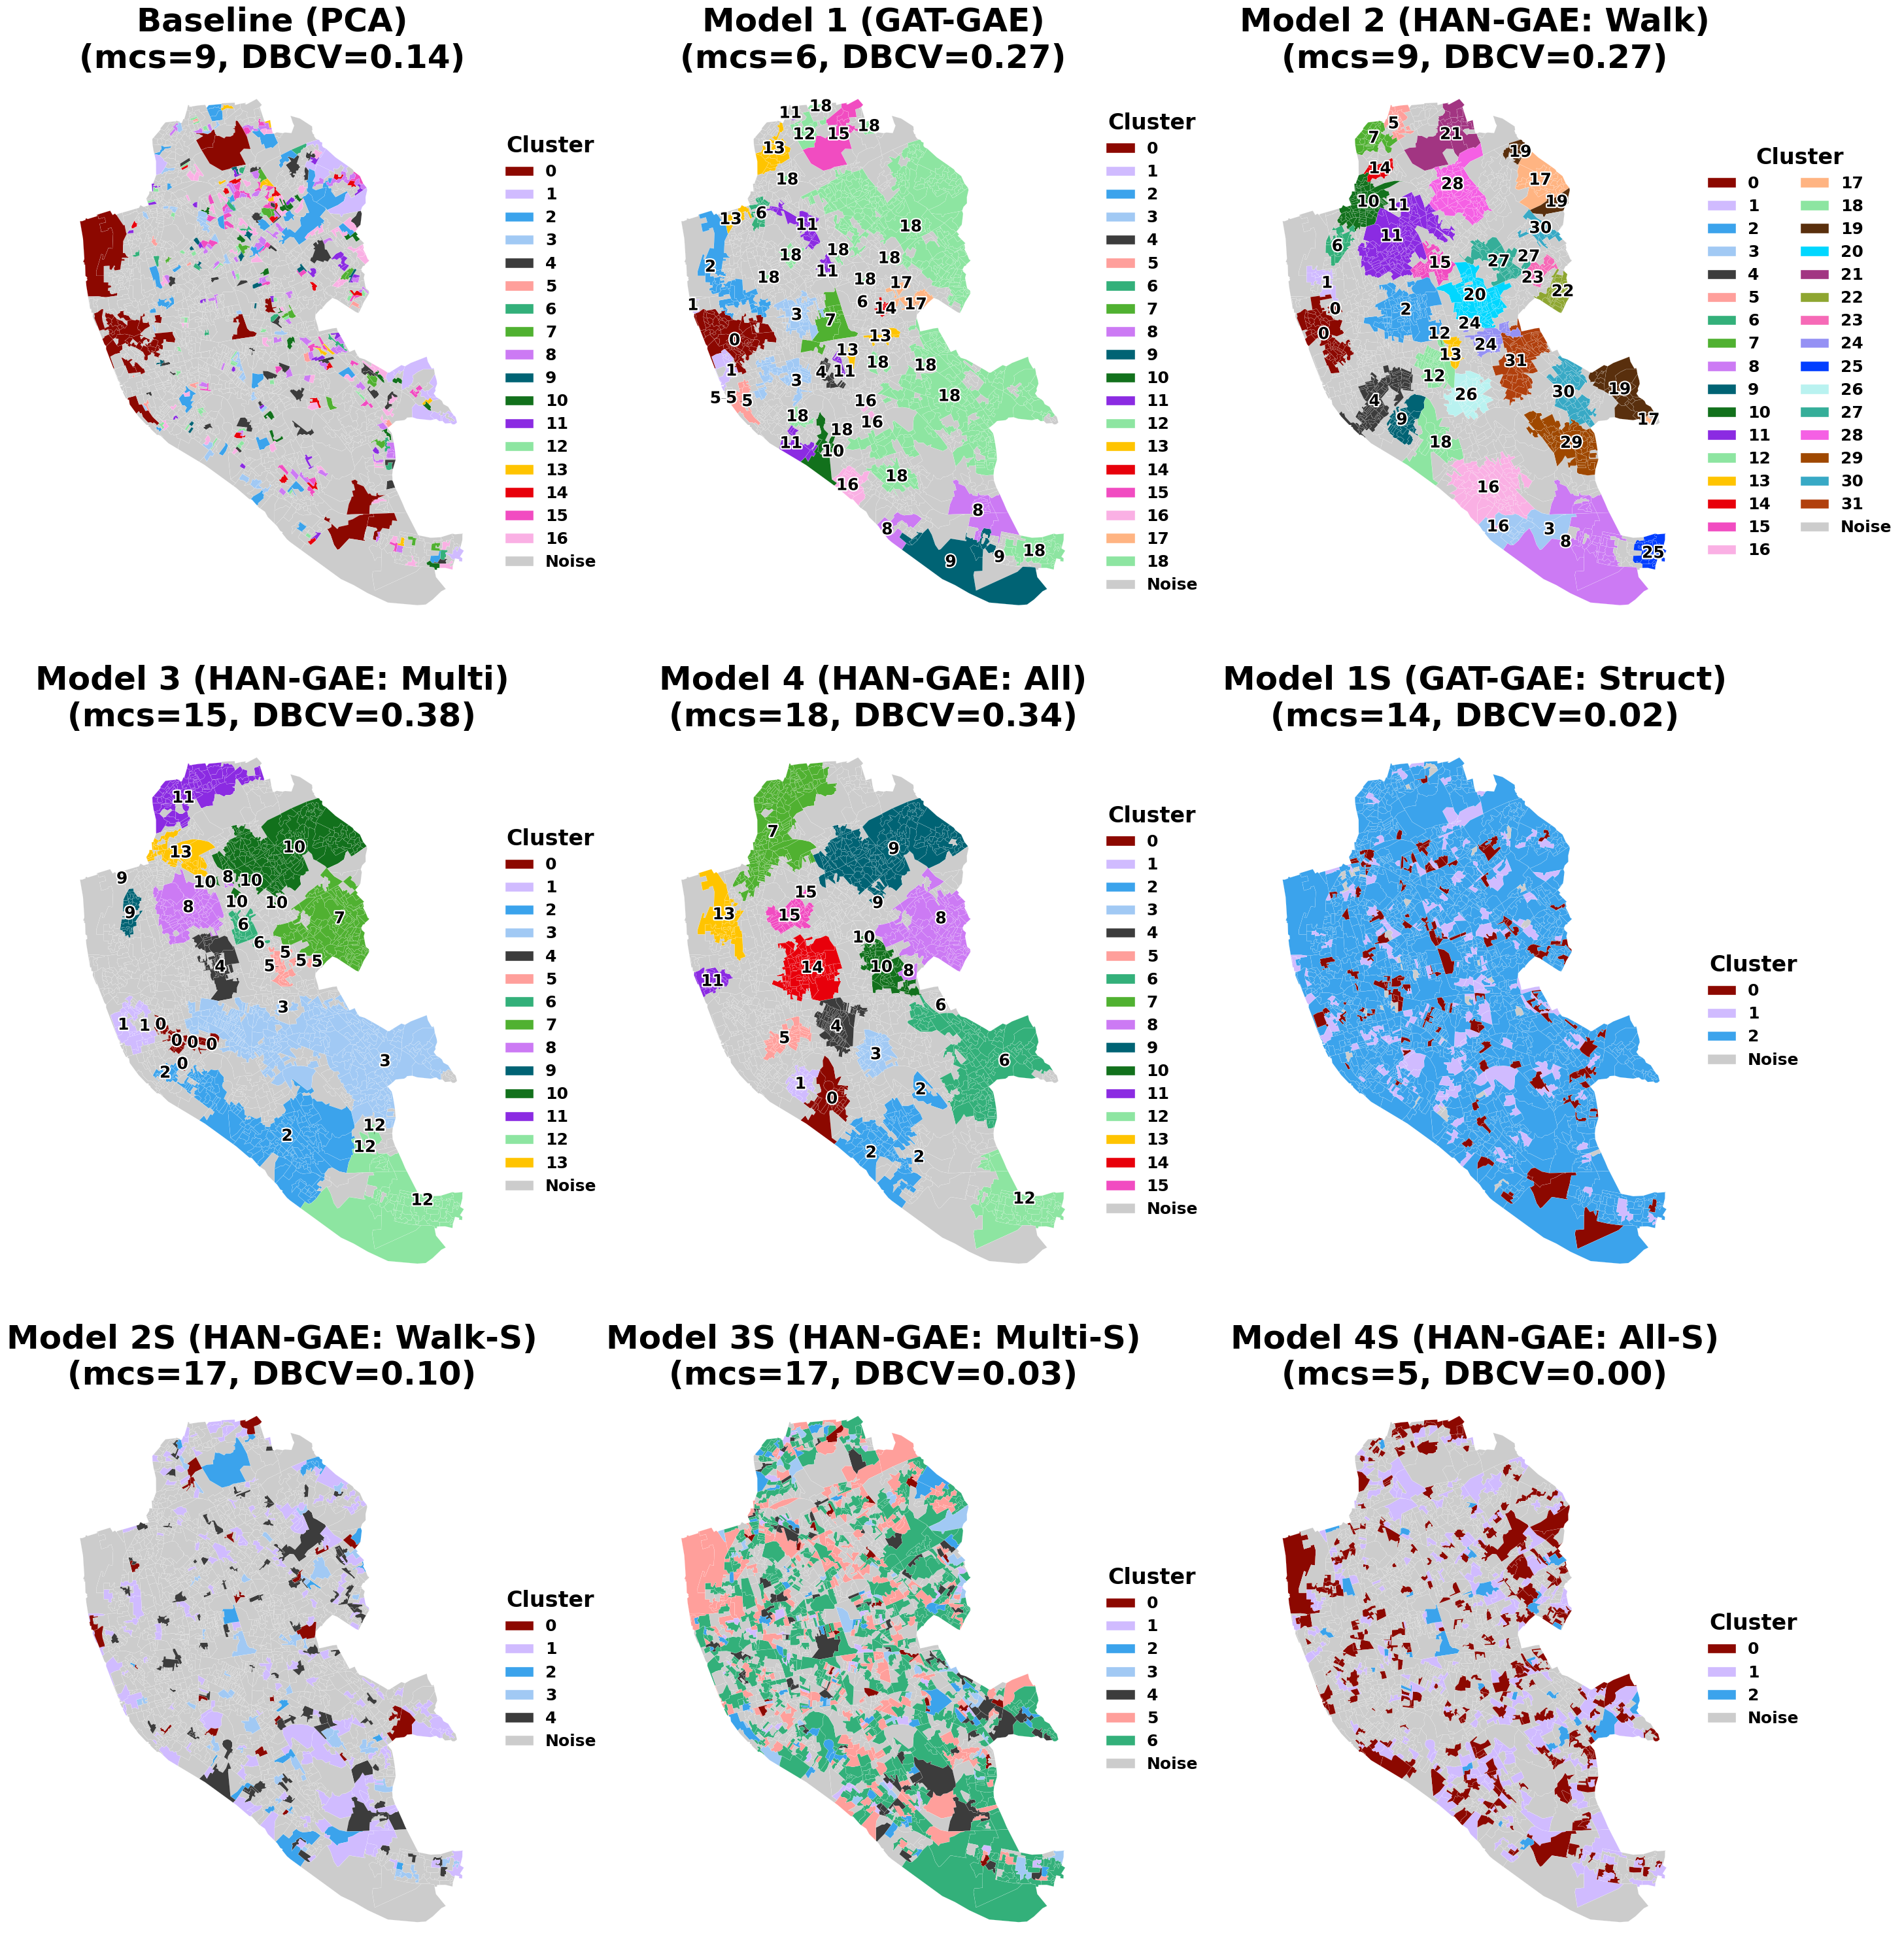

In [9]:
# 3x3 Combined Cluster Map for all 9 models

all_models = list(MODELS.keys())  # 9 models

fig, axes = plt.subplots(3, 3, figsize=(30, 30))

for idx, model_name in enumerate(all_models):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    plot_cluster_map(ax, model_gdfs[model_name], clustering_results[model_name], model_name)

    # Adjust title font size for the compact grid
    ax.set_title(
        f"{model_name}\n"
        f"(mcs={clustering_results[model_name]['mcs']}, "
        f"DBCV={clustering_results[model_name]['dbcv']:.2f})",
        fontsize=36, fontweight="bold"
    )

    # Compact legend for the grid
    legend = ax.get_legend()
    if legend:
        legend.set_title("Cluster")
        plt.setp(legend.get_title(), fontsize=24, fontweight='bold')
        plt.setp(legend.get_texts(), fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "cluster_maps_hdbscan.jpg"), dpi=300, bbox_inches="tight")
plt.show()


## 7. t-SNE Embeddings Visualization

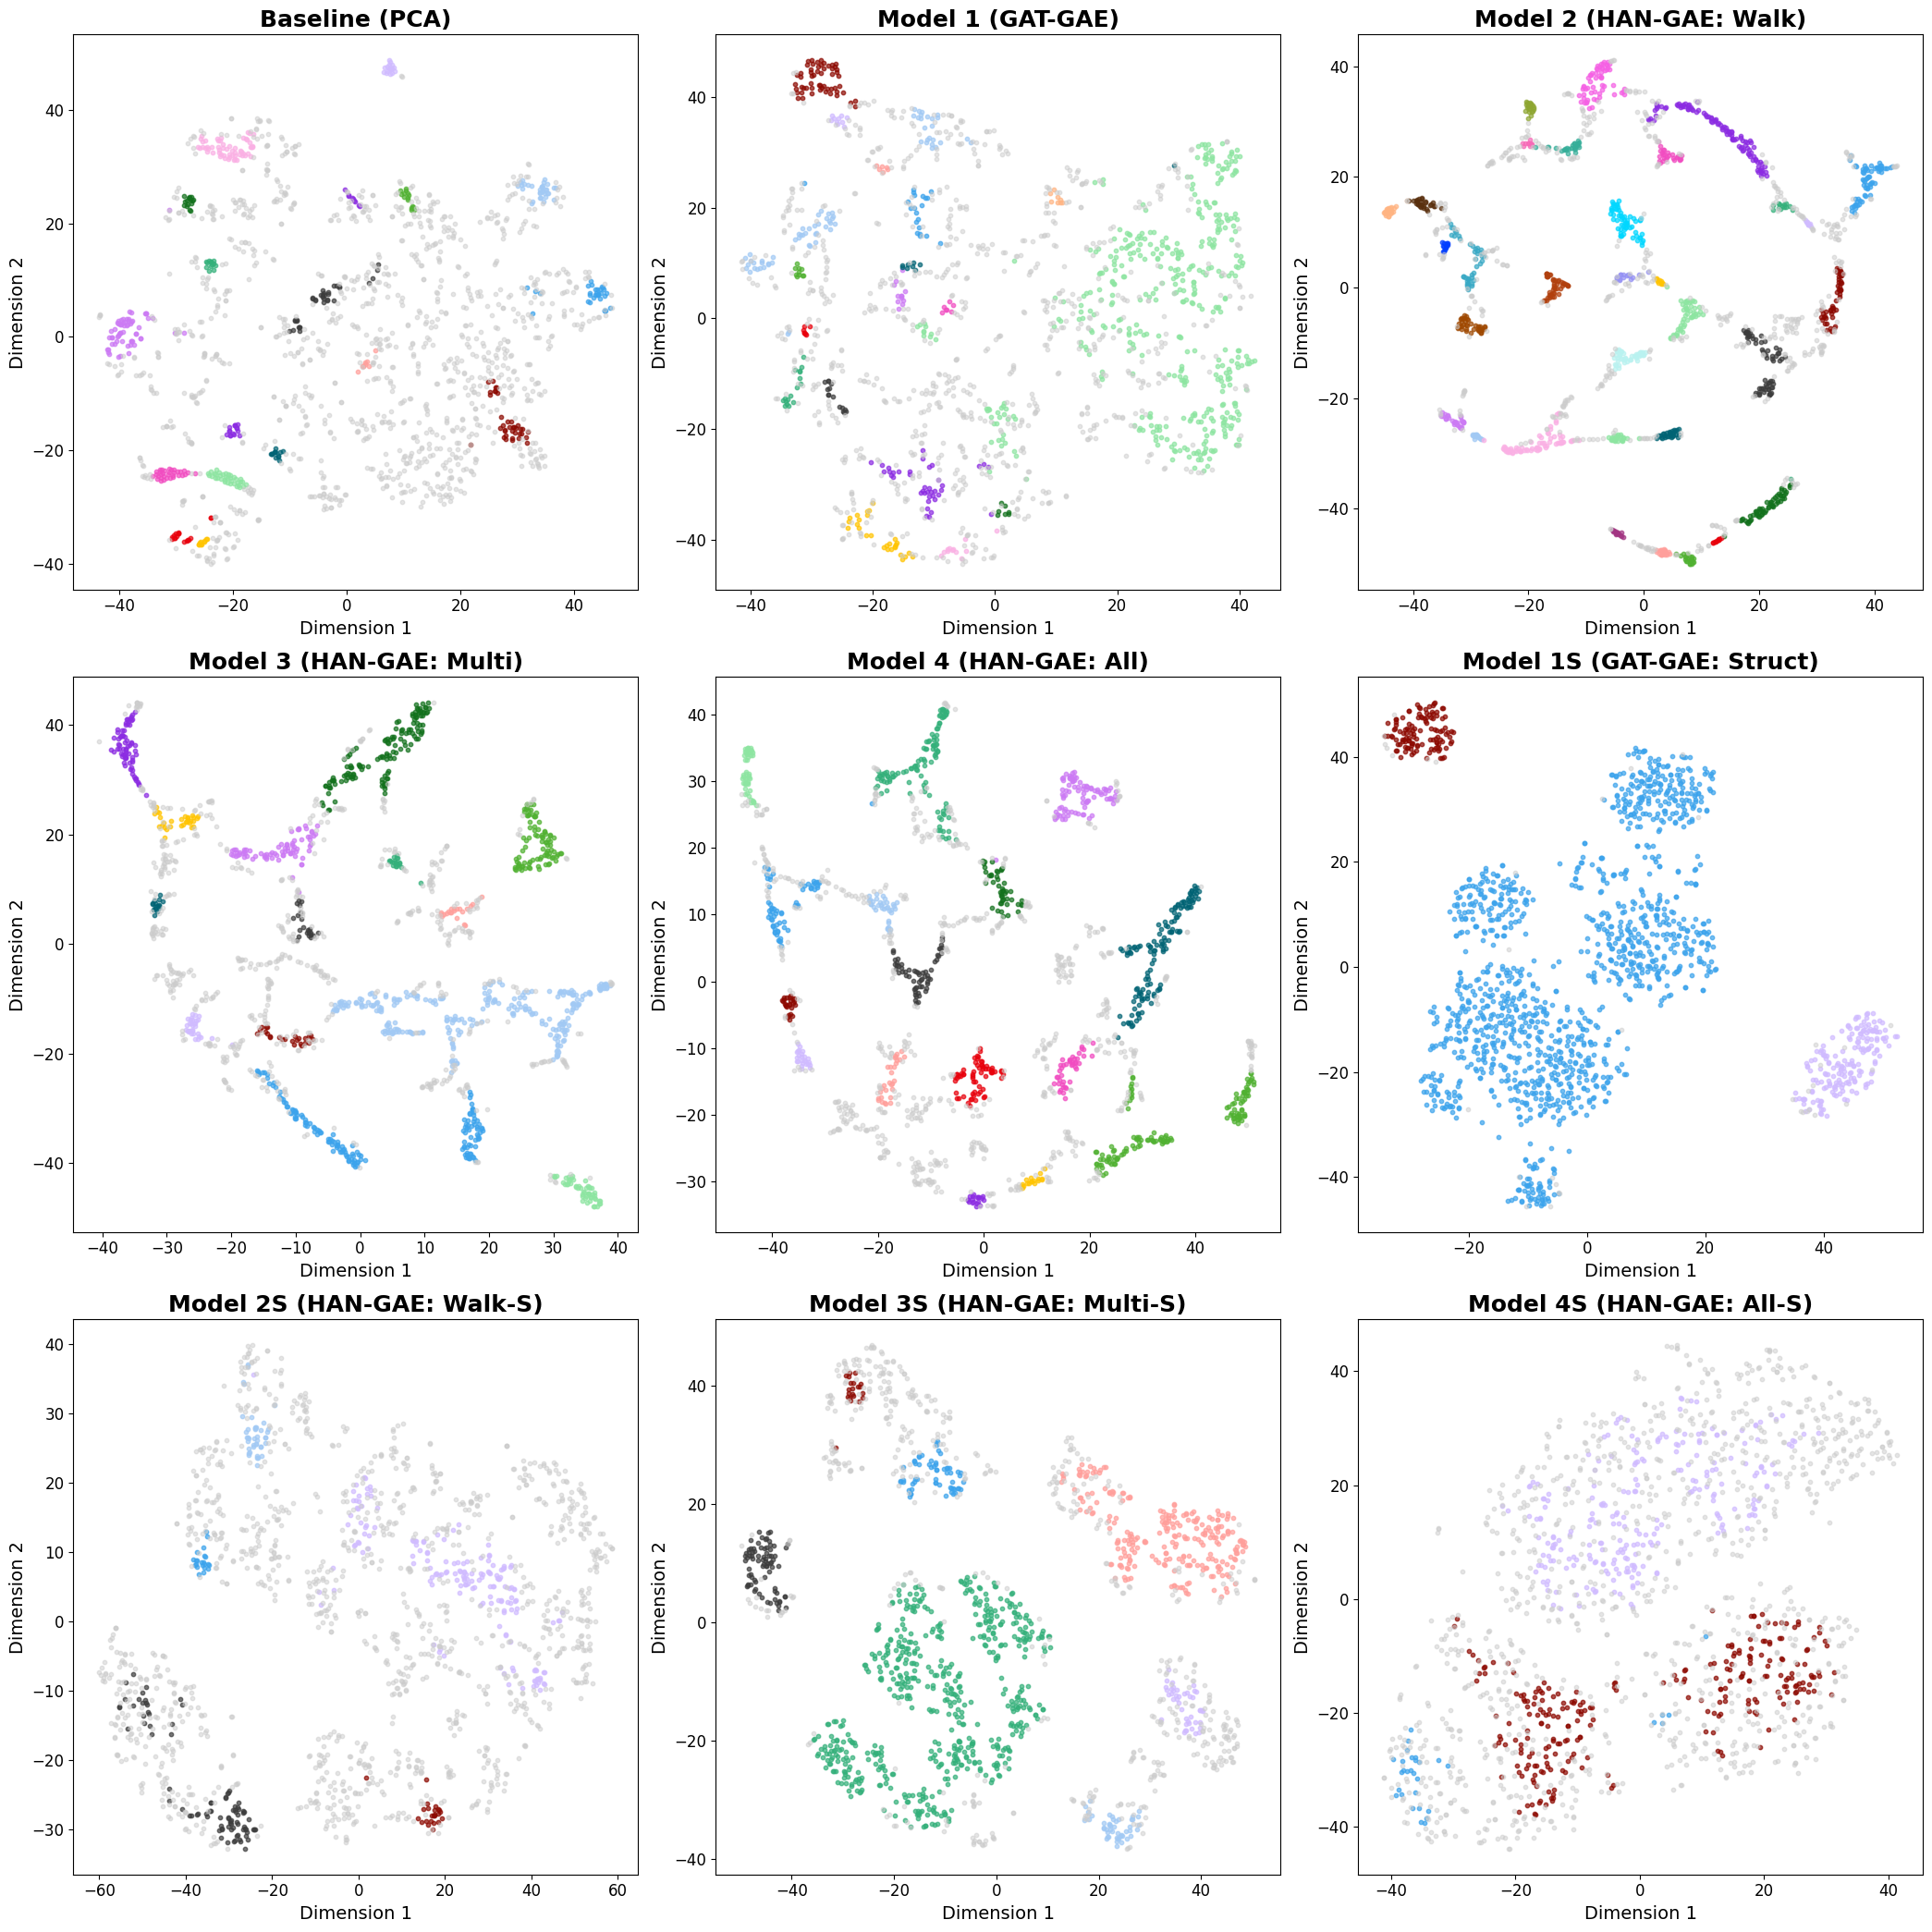

In [10]:
models_to_plot = list(model_gdfs.keys())
n_models = len(models_to_plot)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(21, n_rows * 7))
axes = axes.flatten()

for idx, model_name in enumerate(models_to_plot):
    ax = axes[idx]
    gdf = model_gdfs[model_name]
    result = clustering_results[model_name]
    Z = get_embeddings(gdf, MODELS[model_name]["type"])

    # Rank clusters by cosine similarity to city-centre cluster (same as cluster maps)
    centre_pos = list(gdf.index).index(centre_oa_idx)
    target_label = result["labels"][centre_pos]
    target_label = target_label if target_label != -1 else [l for l in result["labels"] if l != -1][0]
    centroids = pd.DataFrame(Z).assign(label=result["labels"])
    centroids = centroids[centroids["label"] != -1].groupby("label").mean()
    target_vec = centroids.loc[target_label].values.reshape(1, -1)
    cluster_sims = dict(zip(centroids.index, cosine_similarity(target_vec, centroids.values)[0]))
    sorted_labels = sorted(cluster_sims, key=cluster_sims.get, reverse=True)
    rank_color_map = {label: GLOBAL_COLORS[i % len(GLOBAL_COLORS)] for i, label in enumerate(sorted_labels)}

    tsne = TSNE(n_components=2, perplexity=30, random_state=config["seeds"]["tsne"])
    Z_2d = tsne.fit_transform(Z)

    # Plot each cluster with its ranked colour
    for rank, label in enumerate(sorted_labels):
        mask = np.array(result["labels"]) == label
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1],
                   c=rank_color_map[label], s=10, alpha=0.7, label=str(rank))
    # Plot noise points in grey
    noise_mask = np.array(result["labels"]) == -1
    if noise_mask.any():
        ax.scatter(Z_2d[noise_mask, 0], Z_2d[noise_mask, 1],
                   c="#CCCCCC", s=10, alpha=0.5, label="Noise")
    ax.set_title(f"{model_name}", fontsize=18, fontweight="bold")
    ax.set_xlabel("Dimension 1", fontsize=14)
    ax.set_ylabel("Dimension 2", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)

# Hide unused axes
for i in range(len(models_to_plot), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/tsne_embeddings_hdbscan.jpg", dpi=150, bbox_inches="tight")
plt.show()